In [1]:
import os, tensorflow as tf

# Hide all GPUs so TF uses CPU only
tf.config.set_visible_devices([], 'GPU')

# Safe defaults (don’t hurt CPU)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

print("Devices now:", tf.config.list_physical_devices())

Devices now: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-12-09 18:35:31.200469: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import os, tensorflow as tf

# Set this to True if your GPU crashes with cuDNN errors
USE_CPU = False

if USE_CPU:
    tf.config.set_visible_devices([], 'GPU')  # hide GPU -> CPU only
else:
    # safer GPU behavior
    os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
    os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
    for g in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(g, True)

print("GPUs seen by TF:", tf.config.list_physical_devices('GPU'))

GPUs seen by TF: []


In [3]:
import pandas as pd
import tensorflow as tf

def dataset_from_csv(csv_path, img_size=256, batch=4, shuffle=False):
    df = pd.read_csv(csv_path)
    imgs  = tf.constant(df["image_path"].tolist())
    masks = tf.constant(df["mask_path"].tolist())

    def load_pair(i, m):
        x = tf.io.read_file(i)
        x = tf.image.decode_image(x, channels=3, expand_animations=False)
        x = tf.image.resize(x, (img_size, img_size))
        x = tf.cast(x, tf.float32) / 255.0

        y = tf.io.read_file(m)
        y = tf.image.decode_image(y, channels=1, expand_animations=False)
        y = tf.image.resize(y, (img_size, img_size), method="nearest")
        y = tf.cast(y > 127, tf.float32)  # white->1, black->0
        return x, y

    ds = tf.data.Dataset.from_tensor_slices((imgs, masks))
    if shuffle:
        ds = ds.shuffle(2048, reshuffle_each_iteration=True)
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

In [4]:
from tensorflow.keras import layers, models

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(f, 3, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_unet(input_shape=(256,256,3)):
    inp = layers.Input(input_shape)
    c1 = conv_block(inp, 64);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 128);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 256);  p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 512);  p4 = layers.MaxPooling2D()(c4)
    b  = conv_block(p4, 1024)

    def up(x, skip, f):
        x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        return conv_block(x, f)

    u6 = up(b,  c4, 512)
    u7 = up(u6, c3, 256)
    u8 = up(u7, c2, 128)
    u9 = up(u8, c1,  64)
    out = layers.Conv2D(1, 1, activation="sigmoid")(u9)
    return models.Model(inp, out, name="UNetSafe")

unet = build_unet((256,256,3))
unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
unet.summary()


Model: "UNetSafe"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,728 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,864 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,456 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,049,409 (118.44 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [5]:
IMG_SIZE = 256
BATCH    = 4

train_ds = dataset_from_csv("splits/deepglobe/train.csv", img_size=IMG_SIZE, batch=BATCH, shuffle=True)
val_ds   = dataset_from_csv("splits/deepglobe/val.csv",  img_size=IMG_SIZE, batch=BATCH)
test_ds  = dataset_from_csv("splits/deepglobe/test.csv", img_size=IMG_SIZE, batch=BATCH)

xb, yb = next(iter(train_ds))
print("Train batch:", xb.shape, yb.shape)

Train batch: (4, 256, 256, 3) (4, 256, 256, 1)


In [6]:
unet = build_unet((256, 256, 3))
unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [7]:
import tensorflow as tf, os
os.makedirs("checkpoints", exist_ok=True)

backup = tf.keras.callbacks.BackupAndRestore(backup_dir="checkpoints/backup")

ckpt_best = tf.keras.callbacks.ModelCheckpoint(
    "checkpoints/best.keras", monitor="val_loss", mode="min", save_best_only=True
)
ckpt_latest = tf.keras.callbacks.ModelCheckpoint(
    "checkpoints/latest.keras", save_best_only=False
)

csv = tf.keras.callbacks.CSVLogger("checkpoints/train_log.csv", append=True)

In [8]:
from tensorflow import keras

# Rebuild the same model architecture first
unet = build_unet((256, 256, 3))
unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Load the most recent checkpoint
unet.load_weights("checkpoints/latest.keras")

print("Model weights loaded from last checkpoint.")

# Resume training for more epochs
history = unet.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=20,
    epochs=20,
    callbacks=[backup, ckpt_best, ckpt_latest, csv]
)

Model weights loaded from last checkpoint.


/home/zkelias/.conda/envs/mlbd/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 130 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [9]:
from tqdm import tqdm
import numpy as np
import tensorflow as tf

def batch_iou_and_dice(y_true, y_prob, thr=0.5, eps=1e-7):
    y_pred = (y_prob > thr).astype(np.float32)
    inter = (y_true * y_pred).sum(axis=(1,2,3))
    union = (y_true + y_pred).sum(axis=(1,2,3)) - inter
    dice = (2*inter + eps) / (y_true.sum(axis=(1,2,3)) + y_pred.sum(axis=(1,2,3)) + eps)
    iou = (inter + eps) / (union + eps)
    return iou, dice

def evaluate_iou_dice(ds, model, thr=0.5):
    ious, dices = [], []
    
    total_batches = tf.data.experimental.cardinality(ds).numpy()

    for xb, yb in tqdm(ds, total=total_batches, desc="Evaluating"):
        preds = model.predict(xb, verbose=0)
        iou, dice = batch_iou_and_dice(yb.numpy(), preds, thr=thr)
        ious.append(iou)
        dices.append(dice)

    ious = np.concatenate(ious)
    dices = np.concatenate(dices)
    return float(ious.mean()), float(dices.mean())

In [10]:
unet = build_unet((256, 256, 3))
unet.load_weights("checkpoints/best.keras")

unet = build_unet((256, 256, 3))

unet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

unet.load_weights("checkpoints/best.keras")
print("Loaded weights from checkpoints/best.keras")

print("Test Results:")
test_results = unet.evaluate(test_ds)
print(f"\nTest Accuracy: {test_results[1]:.4f}")
print(f"Test Loss:     {test_results[0]:.4f}")

test_iou, test_dice = evaluate_iou_dice(test_ds, unet, thr=0.5)
print(f"\nTest IoU:  {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")

Loaded weights from checkpoints/best.keras
Test Results:


2025-11-13 11:01:37.423693: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f67d4019b10 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 11:01:37.423716: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 11:01:37.561047: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763049698.975787 3016682 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


244/244 ━━━━━━━━━━━━━━━━━━━━ 215s 873ms/step - accuracy: 0.9747 - loss: 0.0687

Test Accuracy: 0.9747
Test Loss:     0.0687


Evaluating: 100%|██████████| 244/244 [03:47<00:00,  1.07it/s]


Test IoU:  0.4683
Test Dice: 0.6056


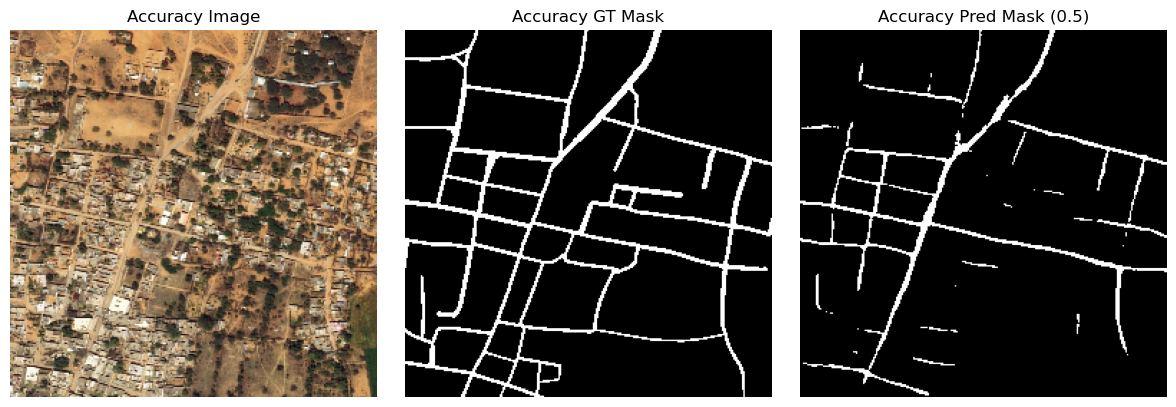

In [17]:
sample_ds = (
    test_ds
    .unbatch()
    .shuffle(1000, reshuffle_each_iteration=True)
    .take(1)
)

for img, mtrue in sample_ds:
    img = img.numpy()
    mtrue = mtrue.numpy()
    break

pred_prob = unet.predict(tf.expand_dims(img, 0), verbose=0)[0, :, :, 0]

thr = 0.5
pmask = (pred_prob > thr).astype(np.float32)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Accuracy Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Accuracy GT Mask")
plt.imshow(mtrue[:,0:, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title(f"Accuracy Pred Mask ({thr})")
plt.imshow(pmask, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

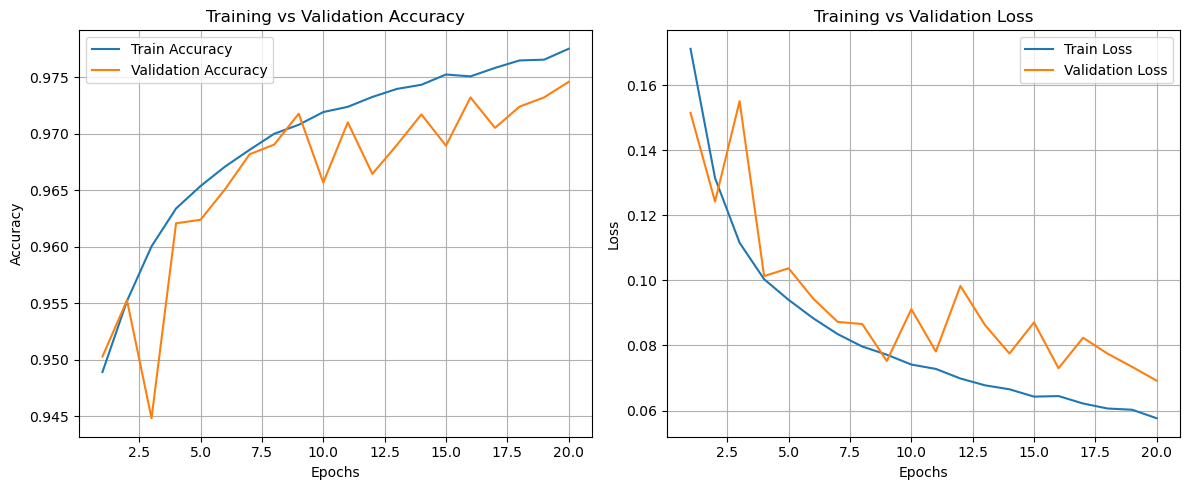

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training log written by CSVLogger
log_path = "checkpoints/train_log.csv"
log = pd.read_csv(log_path)

# If there's an 'epoch' column, turn it into 1-based epoch numbers
if "epoch" in log.columns:
    epochs = log["epoch"] + 1
else:
    epochs = range(1, len(log) + 1)

train_acc  = log["accuracy"]
val_acc    = log["val_accuracy"]
train_loss = log["loss"]
val_loss   = log["val_loss"]

plt.figure(figsize=(12, 5))

# ---- Accuracy plot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ---- Loss plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
